In [1]:
%run ./resources/library.py

In [2]:
style_notebook()

# Notebook 2: Exploring TB and Socio-economic Indicators, Part 1

## Goals

Our goal for this TB exploration notebook is to construct a "gapminder" for TB data and a time series choropleth map. See figures below.

![Gapminder for TB](images/gapminder-for-tb.png)

**Figure 1**. Interactive Gapminder bubble chart for TB data

![Choropleth Timeseries for TB](images/choropleth-timeseries-tb.png)

**Figure 2**. Interactive choropleth map for TB data

## Steps

Notebook 2
1. Set up data exploration environment
2. Download and clean up data from the WHO, World Bank

## STEP 1. Set up data exploration environment

To create visualizations, we will use Plotly Express. You can learn more about Plotly Express from:
1. [Plotly GitHub Site](https://github.com/plotly/plotly_express) (GitHub)
2. [Jupyter Notebook Example](https://www.plotly.express/)
3. Some articles written about it [here](https://medium.com/@plotlygraphs/introducing-plotly-express-808df010143d) and [here](https://towardsdatascience.com/plotly-express-the-good-the-bad-and-the-ugly-dc941649687c)

In [3]:
import plotly.express as px
import plotly

plotly.__version__

'4.2.1'

We will also use our Swiss Army knife for data science, `pandas`.

In [4]:
import pandas as pd
pd.__version__

'0.25.3'

In [5]:
pd.set_option('max_colwidth', 150)
pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 1000)

**`missingno`**: Missing data visualization module for Python 

Read more about it here: https://github.com/ResidentMario/missingno

In [6]:
import missingno as mno
mno.__version__

'0.4.2'

In [7]:
import matplotlib

matplotlib.__version__

'3.1.2'

In [8]:
%matplotlib inline

In [9]:
import numpy as np

np.__version__

'1.17.3'

## STEP 2. Download and clean up data

All data files are found in the `resources` folder. You can also download these using the links and instructions below.

### 1. World Health Organization (WHO), estimates of TB burden

Data from 2000-2017 provided by countries to WHO and estimates of TB burden generated by WHO for the Global Tuberculosis Report. 

1. Source, data: https://extranet.who.int/tme/generateCSV.asp?ds=estimates
2. Source, metadata: https://extranet.who.int/tme/generateCSV.asp?ds=dictionary
3. Instructions: No need to modify CSV download.

**Aggregate Data**

In [10]:
tb_df1 = pd.read_csv("resources/TB_burden_countries_2019-07-03.csv")

tb_df1.head()

,country,iso2,iso3,iso_numeric,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,e_inc_num,e_inc_num_lo,e_inc_num_hi,e_tbhiv_prct,e_tbhiv_prct_lo,e_tbhiv_prct_hi,e_inc_tbhiv_100k,e_inc_tbhiv_100k_lo,e_inc_tbhiv_100k_hi,e_inc_tbhiv_num,e_inc_tbhiv_num_lo,e_inc_tbhiv_num_hi,e_mort_exc_tbhiv_100k,e_mort_exc_tbhiv_100k_lo,e_mort_exc_tbhiv_100k_hi,e_mort_exc_tbhiv_num,e_mort_exc_tbhiv_num_lo,e_mort_exc_tbhiv_num_hi,e_mort_tbhiv_100k,e_mort_tbhiv_100k_lo,e_mort_tbhiv_100k_hi,e_mort_tbhiv_num,e_mort_tbhiv_num_lo,e_mort_tbhiv_num_hi,e_mort_100k,e_mort_100k_lo,e_mort_100k_hi,e_mort_num,e_mort_num_lo,e_mort_num_hi,cfr,cfr_lo,cfr_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,20093756,190.0,123.0,271.0,38000,25000,54000,0.36,0.12,0.72,0.68,0.20,1.50,140.0,40.0,290.0,67.0,39.0,103.0,14000,7800.0,21000.0,0.15,0.00,0.77,31,0,160,67.0,39.0,104.0,14000,7800,21000,NaN,NaN,NaN,35.0,19.0,13.0,29.0
1,Afghanistan,AF,AFG,4,EMR,2001,20966463,189.0,123.0,271.0,40000,26000,57000,0.30,0.10,0.61,0.57,0.16,1.20,120.0,34.0,260.0,62.0,36.0,95.0,13000,7500.0,20000.0,0.17,0.00,0.62,35,1,130,62.0,36.0,95.0,13000,7500,20000,NaN,NaN,NaN,48.0,26.0,18.0,39.0
2,Afghanistan,AF,AFG,4,EMR,2002,21979923,189.0,122.0,270.0,42000,27000,59000,0.26,0.09,0.52,0.49,0.15,1.00,110.0,32.0,230.0,56.0,33.0,86.0,12000,7200.0,19000.0,0.27,0.08,0.58,60,17,130,56.0,33.0,86.0,12000,7200,19000,NaN,NaN,NaN,63.0,33.0,23.0,51.0
3,Afghanistan,AF,AFG,4,EMR,2003,23064851,189.0,122.0,270.0,44000,28000,62000,0.23,0.09,0.45,0.44,0.14,0.92,100.0,31.0,210.0,57.0,33.0,87.0,13000,7700.0,20000.0,0.25,0.07,0.52,57,17,120,57.0,33.0,88.0,13000,7700,20000,NaN,NaN,NaN,60.0,32.0,22.0,49.0
4,Afghanistan,AF,AFG,4,EMR,2004,24118979,189.0,122.0,270.0,46000,29000,65000,0.22,0.08,0.42,0.41,0.13,0.85,100.0,32.0,210.0,51.0,30.0,77.0,12000,7100.0,19000.0,0.21,0.07,0.43,50,16,100,51.0,30.0,77.0,12000,7200,19000,NaN,NaN,NaN,76.0,40.0,28.0,62.0


In [11]:
tb_df1.columns

Index(['country', 'iso2', 'iso3', 'iso_numeric', 'g_whoregion', 'year',
       'e_pop_num', 'e_inc_100k', 'e_inc_100k_lo', 'e_inc_100k_hi',
       'e_inc_num', 'e_inc_num_lo', 'e_inc_num_hi', 'e_tbhiv_prct',
       'e_tbhiv_prct_lo', 'e_tbhiv_prct_hi', 'e_inc_tbhiv_100k',
       'e_inc_tbhiv_100k_lo', 'e_inc_tbhiv_100k_hi', 'e_inc_tbhiv_num',
       'e_inc_tbhiv_num_lo', 'e_inc_tbhiv_num_hi', 'e_mort_exc_tbhiv_100k',
       'e_mort_exc_tbhiv_100k_lo', 'e_mort_exc_tbhiv_100k_hi',
       'e_mort_exc_tbhiv_num', 'e_mort_exc_tbhiv_num_lo',
       'e_mort_exc_tbhiv_num_hi', 'e_mort_tbhiv_100k', 'e_mort_tbhiv_100k_lo',
       'e_mort_tbhiv_100k_hi', 'e_mort_tbhiv_num', 'e_mort_tbhiv_num_lo',
       'e_mort_tbhiv_num_hi', 'e_mort_100k', 'e_mort_100k_lo',
       'e_mort_100k_hi', 'e_mort_num', 'e_mort_num_lo', 'e_mort_num_hi', 'cfr',
       'cfr_lo', 'cfr_hi', 'c_newinc_100k', 'c_cdr', 'c_cdr_lo', 'c_cdr_hi'],
      dtype='object')

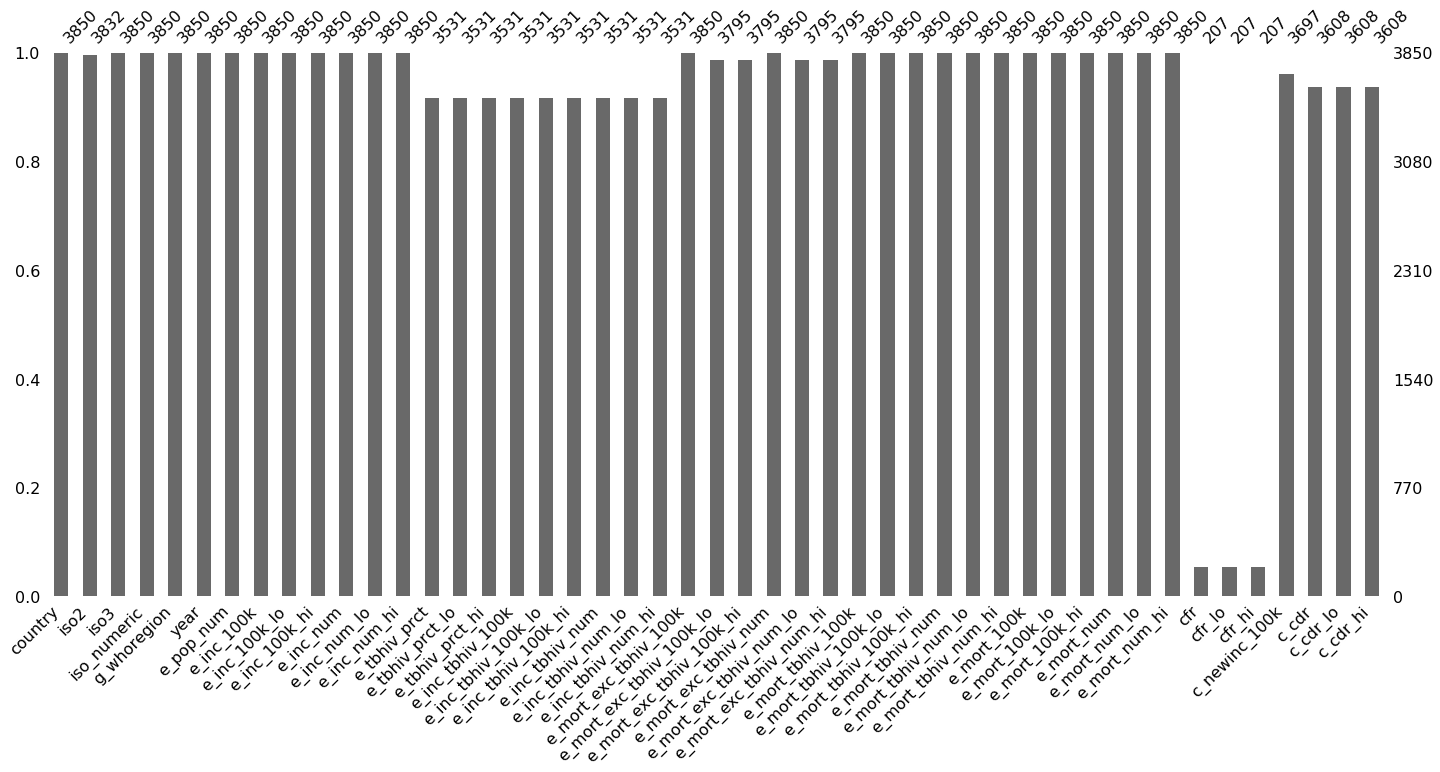

In [12]:
mno.bar(tb_df1)

**Data Dictionary**

You can look up the definitions of the columns above using the data dictionary dataframe.

In [13]:
tb_dict_df = pd.read_csv("resources/TB_data_dictionary_2019-07-03.csv")

tb_dict_df.head()

,variable_name,dataset,code_list,definition
0,budget_cpp_dstb,Budget,NaN,"Average cost of drugs budgeted per patient for drug-susceptible TB treatment, excluding buffer stock (US Dollars)"
1,budget_cpp_mdr,Budget,NaN,"Average cost of drugs budgeted per patient for MDR-TB treatment, excluding buffer stock (US Dollars)"
2,budget_cpp_xdr,Budget,NaN,"Average cost of drugs budgeted per patient for XDR-TB treatment, excluding buffer stock (US Dollars)"
3,budget_fld,Budget,NaN,Budget required for drugs to treat drug-susceptible TB (US Dollars)
4,budget_lab,Budget,NaN,"Budget required for laboratory infrastructure, equipment and supplies (US Dollars)"


You can also query the dataframe for specific variables, as shown below.

In [14]:
tb_dict_df.query("variable_name=='e_mort_num'")

,variable_name,dataset,code_list,definition
103,e_mort_num,Estimates,NaN,Estimated number of deaths from TB (all forms)


In [15]:
tb_dict_df.query("variable_name=='e_inc_100k'")

,variable_name,dataset,code_list,definition
76,e_inc_100k,Estimates,NaN,Estimated incidence (all forms) per 100 000 population


In [16]:
tb_dict_df.query("variable_name=='e_inc_tbhiv_100k'")

,variable_name,dataset,code_list,definition
85,e_inc_tbhiv_100k,Estimates,NaN,Estimated incidence of TB cases who are HIV-positive per 100 000 population


#### Prepare for second merge between TB data and the merged WB data

In [17]:
tb_df1.head()

,country,iso2,iso3,iso_numeric,g_whoregion,year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,e_inc_num,e_inc_num_lo,e_inc_num_hi,e_tbhiv_prct,e_tbhiv_prct_lo,e_tbhiv_prct_hi,e_inc_tbhiv_100k,e_inc_tbhiv_100k_lo,e_inc_tbhiv_100k_hi,e_inc_tbhiv_num,e_inc_tbhiv_num_lo,e_inc_tbhiv_num_hi,e_mort_exc_tbhiv_100k,e_mort_exc_tbhiv_100k_lo,e_mort_exc_tbhiv_100k_hi,e_mort_exc_tbhiv_num,e_mort_exc_tbhiv_num_lo,e_mort_exc_tbhiv_num_hi,e_mort_tbhiv_100k,e_mort_tbhiv_100k_lo,e_mort_tbhiv_100k_hi,e_mort_tbhiv_num,e_mort_tbhiv_num_lo,e_mort_tbhiv_num_hi,e_mort_100k,e_mort_100k_lo,e_mort_100k_hi,e_mort_num,e_mort_num_lo,e_mort_num_hi,cfr,cfr_lo,cfr_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,20093756,190.0,123.0,271.0,38000,25000,54000,0.36,0.12,0.72,0.68,0.20,1.50,140.0,40.0,290.0,67.0,39.0,103.0,14000,7800.0,21000.0,0.15,0.00,0.77,31,0,160,67.0,39.0,104.0,14000,7800,21000,NaN,NaN,NaN,35.0,19.0,13.0,29.0
1,Afghanistan,AF,AFG,4,EMR,2001,20966463,189.0,123.0,271.0,40000,26000,57000,0.30,0.10,0.61,0.57,0.16,1.20,120.0,34.0,260.0,62.0,36.0,95.0,13000,7500.0,20000.0,0.17,0.00,0.62,35,1,130,62.0,36.0,95.0,13000,7500,20000,NaN,NaN,NaN,48.0,26.0,18.0,39.0
2,Afghanistan,AF,AFG,4,EMR,2002,21979923,189.0,122.0,270.0,42000,27000,59000,0.26,0.09,0.52,0.49,0.15,1.00,110.0,32.0,230.0,56.0,33.0,86.0,12000,7200.0,19000.0,0.27,0.08,0.58,60,17,130,56.0,33.0,86.0,12000,7200,19000,NaN,NaN,NaN,63.0,33.0,23.0,51.0
3,Afghanistan,AF,AFG,4,EMR,2003,23064851,189.0,122.0,270.0,44000,28000,62000,0.23,0.09,0.45,0.44,0.14,0.92,100.0,31.0,210.0,57.0,33.0,87.0,13000,7700.0,20000.0,0.25,0.07,0.52,57,17,120,57.0,33.0,88.0,13000,7700,20000,NaN,NaN,NaN,60.0,32.0,22.0,49.0
4,Afghanistan,AF,AFG,4,EMR,2004,24118979,189.0,122.0,270.0,46000,29000,65000,0.22,0.08,0.42,0.41,0.13,0.85,100.0,32.0,210.0,51.0,30.0,77.0,12000,7100.0,19000.0,0.21,0.07,0.43,50,16,100,51.0,30.0,77.0,12000,7200,19000,NaN,NaN,NaN,76.0,40.0,28.0,62.0


For ease of merges between dataframes, we will use common field names:
1. `Country` (country name)
2. `ISO_Alpha` (3-letter ISO country code)
3. `Year`

In [18]:
tb_df2 = tb_df1.rename(\
        columns={'country': 'Country', 'iso3': 'ISO_Alpha', 'year': 'Year'})

tb_df2.head()

,Country,iso2,ISO_Alpha,iso_numeric,g_whoregion,Year,e_pop_num,e_inc_100k,e_inc_100k_lo,e_inc_100k_hi,e_inc_num,e_inc_num_lo,e_inc_num_hi,e_tbhiv_prct,e_tbhiv_prct_lo,e_tbhiv_prct_hi,e_inc_tbhiv_100k,e_inc_tbhiv_100k_lo,e_inc_tbhiv_100k_hi,e_inc_tbhiv_num,e_inc_tbhiv_num_lo,e_inc_tbhiv_num_hi,e_mort_exc_tbhiv_100k,e_mort_exc_tbhiv_100k_lo,e_mort_exc_tbhiv_100k_hi,e_mort_exc_tbhiv_num,e_mort_exc_tbhiv_num_lo,e_mort_exc_tbhiv_num_hi,e_mort_tbhiv_100k,e_mort_tbhiv_100k_lo,e_mort_tbhiv_100k_hi,e_mort_tbhiv_num,e_mort_tbhiv_num_lo,e_mort_tbhiv_num_hi,e_mort_100k,e_mort_100k_lo,e_mort_100k_hi,e_mort_num,e_mort_num_lo,e_mort_num_hi,cfr,cfr_lo,cfr_hi,c_newinc_100k,c_cdr,c_cdr_lo,c_cdr_hi
0,Afghanistan,AF,AFG,4,EMR,2000,20093756,190.0,123.0,271.0,38000,25000,54000,0.36,0.12,0.72,0.68,0.20,1.50,140.0,40.0,290.0,67.0,39.0,103.0,14000,7800.0,21000.0,0.15,0.00,0.77,31,0,160,67.0,39.0,104.0,14000,7800,21000,NaN,NaN,NaN,35.0,19.0,13.0,29.0
1,Afghanistan,AF,AFG,4,EMR,2001,20966463,189.0,123.0,271.0,40000,26000,57000,0.30,0.10,0.61,0.57,0.16,1.20,120.0,34.0,260.0,62.0,36.0,95.0,13000,7500.0,20000.0,0.17,0.00,0.62,35,1,130,62.0,36.0,95.0,13000,7500,20000,NaN,NaN,NaN,48.0,26.0,18.0,39.0
2,Afghanistan,AF,AFG,4,EMR,2002,21979923,189.0,122.0,270.0,42000,27000,59000,0.26,0.09,0.52,0.49,0.15,1.00,110.0,32.0,230.0,56.0,33.0,86.0,12000,7200.0,19000.0,0.27,0.08,0.58,60,17,130,56.0,33.0,86.0,12000,7200,19000,NaN,NaN,NaN,63.0,33.0,23.0,51.0
3,Afghanistan,AF,AFG,4,EMR,2003,23064851,189.0,122.0,270.0,44000,28000,62000,0.23,0.09,0.45,0.44,0.14,0.92,100.0,31.0,210.0,57.0,33.0,87.0,13000,7700.0,20000.0,0.25,0.07,0.52,57,17,120,57.0,33.0,88.0,13000,7700,20000,NaN,NaN,NaN,60.0,32.0,22.0,49.0
4,Afghanistan,AF,AFG,4,EMR,2004,24118979,189.0,122.0,270.0,46000,29000,65000,0.22,0.08,0.42,0.41,0.13,0.85,100.0,32.0,210.0,51.0,30.0,77.0,12000,7100.0,19000.0,0.21,0.07,0.43,50,16,100,51.0,30.0,77.0,12000,7200,19000,NaN,NaN,NaN,76.0,40.0,28.0,62.0


#### Pickle WHO TB data set

In [19]:
tb_df2.to_pickle('outputs/tb_df2.pickle')
tb_dict_df.to_pickle('outputs/tb_dict_df.pickle')

### 2. World Bank (WB), World Gross Domestic Product (GDP) Data, 1960-2018

**Aggregate Data, GDP**

1. Source: http://api.worldbank.org/v2/en/indicator/NY.GDP.MKTP.CD?downloadformat=csv
2. License: https://datacatalog.worldbank.org/public-licenses#cc-by
3. Note: The downloaded zip file has 3 CSV files: data, metadata and indicator metatadata (first two are used here). The data CSV file has 4 rows at the top that should be deleted.

In [20]:
wb_gdp_df1 = pd.read_csv("resources/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_123-V2.csv")

wb_gdp_df1.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6472.502029,7885.796545,9764.789979,11392.455810,12307.311740,13496.003390,14046.504000,14936.827040,16241.046320,16439.356360,16586.068440,17927.749640,19078.343190,19356.203390,20620.700630,20669.031970,20436.887130,20833.761610,22569.974990,23300.039560,24045.272480,25835.132670,27084.703690,24630.453710,23512.602600,24985.993280,24713.698050,25025.099560,25533.569780,25796.380250,25239.600410,25630.266490,NaN
1,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,59.773194,59.860874,58.458015,78.706388,82.095231,101.108305,137.594352,160.898589,129.108323,129.329713,156.518939,159.567578,135.317308,143.14465,173.653765,186.510897,197.445508,224.224797,247.354106,275.738198,272.655286,264.111317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179.426495,190.684009,211.381969,242.031379,263.733735,359.693480,364.660465,438.076034,543.303042,591.162347,641.872034,637.165044,613.856333,578.466353,547.228110,556.302138,520.896603
2,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,710.981648,642.383858,619.961357,623.440585,637.715231,758.237576,685.270085,756.261853,792.303120,890.554137,947.704182,865.692730,656.361756,441.200673,328.673295,397.179451,522.643807,514.295223,423.593660,387.784316,556.836318,527.333529,872.494492,982.960899,1255.564045,1902.422346,2599.566464,3121.995637,4080.941410,3122.780766,3587.883798,4615.468028,5100.095808,5254.882338,5408.410496,4166.979684,3506.072885,4095.812942,3432.385736
3,Albania,ALB,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,639.484736,639.865909,693.873475,674.793383,652.774321,697.995597,617.230435,336.586995,200.852220,367.279225,586.416340,750.604449,1009.977668,717.380567,813.790264,1033.241693,1126.683318,1281.659393,1425.124849,1846.118813,2373.579844,2673.787283,2972.743265,3595.037163,4370.539925,4114.134899,4094.358816,4437.177794,4247.614342,4413.082887,4578.667934,3952.830781,4124.108543,4532.889198,5253.630064
4,Andorra,AND,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3238.556850,3498.173652,4217.173581,5342.16856,6319.739034,7169.101006,7152.375134,7751.370216,9129.706185,11820.849390,12377.411650,10372.232830,9610.266308,8022.654781,7728.906695,7774.393829,10361.815980,12616.167570,14304.356960,15166.437850,18878.505970,19532.540150,20547.711790,16516.471030,16234.809010,18461.064860,19017.174590,18353.059720,18894.521500,19261.710500,21936.530100,22228.846490,24741.493570,32776.442270,38503.479610,41282.020120,43747.691850,48582.220880,47785.089270,43338.866760,39736.354060,41100.729940,38392.943900,40626.751630,42300.334130,36039.653500,37224.108920,39134.393370,42029.762740


Because this data set is just about one indicator, GDP, let's drop the two columns, `Indicator Name` and `Indicator Code` and rename `Country Name` to `Country` and `Country Code` to `ISO_Alpha`.

Python indices start with zero), hence:
1. Column 0: "Country Name"
2. Column 1: "Country Code"
3. Column 2: "Indicator Name"
4. Column 3: "Indicator Code"

In [21]:
# columns to be dropped, as above
cols = [2,3]

# drop columns 2 and 3 and rename columns
wb_gdp_df2 = wb_gdp_df1.drop(wb_gdp_df1.columns[cols],axis=1)
wb_gdp_df3 = wb_gdp_df2.rename(columns={ "Country Name": "Country", \
                                        "Country Code": "ISO_Alpha" })
wb_gdp_df3

,Country,ISO_Alpha,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6472.502029,7885.796545,9764.789979,11392.455810,12307.311740,13496.003390,14046.504000,14936.827040,16241.046320,16439.356360,16586.068440,17927.749640,19078.343190,19356.203390,20620.700630,20669.031970,20436.887130,20833.761610,22569.974990,23300.039560,24045.272480,25835.132670,27084.703690,24630.453710,23512.602600,24985.993280,24713.698050,25025.099560,25533.569780,25796.380250,25239.600410,25630.266490,NaN
1,Afghanistan,AFG,59.773194,59.860874,58.458015,78.706388,82.095231,101.108305,137.594352,160.898589,129.108323,129.329713,156.518939,159.567578,135.317308,143.144650,173.653765,186.510897,197.445508,224.224797,247.354106,275.738198,272.655286,264.111317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179.426495,190.684009,211.381969,242.031379,263.733735,359.693480,364.660465,438.076034,543.303042,591.162347,641.872034,637.165044,613.856333,578.466353,547.228110,556.302138,520.896603
2,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,710.981648,642.383858,619.961357,623.440585,637.715231,758.237576,685.270085,756.261853,792.303120,890.554137,947.704182,865.692730,656.361756,441.200673,328.673295,397.179451,522.643807,514.295223,423.593660,387.784316,556.836318,527.333529,872.494492,982.960899,1255.564045,1902.422346,2599.566464,3121.995637,4080.941410,3122.780766,3587.883798,4615.468028,5100.095808,5254.882338,5408.410496,4166.979684,3506.072885,4095.812942,3432.385736
3,Albania,ALB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,639.484736,639.865909,693.873475,674.793383,652.774321,697.995597,617.230435,336.586995,200.852220,367.279225,586.416340,750.604449,1009.977668,717.380567,813.790264,1033.241693,1126.683318,1281.659393,1425.124849,1846.118813,2373.579844,2673.787283,2972.743265,3595.037163,4370.539925,4114.134899,4094.358816,4437.177794,4247.614342,4413.082887,4578.667934,3952.830781,4124.108543,4532.889198,5253.630064
4,Andorra,AND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3238.556850,3498.173652,4217.173581,5342.168560,6319.739034,7169.101006,7152.375134,7751.370216,9129.706185,11820.849390,12377.411650,10372.232830,9610.266308,8022.654781,7728.906695,7774.393829,10361.815980,12616.167570,14304.356960,15166.437850,18878.505970,19532.540150,20547.711790,16516.471030,16234.809010,18461.064860,19017.174590,18353.059720,18894.521500,19261.710500,21936.530100,22228.846490,24741.493570,32776.442270,38503.479610,41282.020120,43747.691850,48582.220880,47785.089270,43338.866760,39736.354060,41100.729940,38392.943900,40626.751630,42300.334130,36039.653500,37224.108920,39134.393370,42029.762740
5,Arab World,ARB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,222.369330,237.535728,260.347312,293.484093,340.546888,419.559635,774.860012,832.035536,1002.708725,1120.662286,1191.139891,1561.383341,2051.243700,2048.663402,1862.315911,1696.684867,1669.749315,1604.000838,1486.622766,1540.010320,1472.408417,1501.826007,2007.163325,1926.490561,2024.721069,1994.346508,1986.811528,2069.987627,2233.191828,2316.393371,2186.749825,2330.191833,2603.872069,2508.212187,2474.779797,2734.318941,3132.327812,3762.767087,4356.152316,4959.915010,6143.170152,5182.363881,5945.678558,6889.091806,7503.174184,7551.282834,7497.726925,6458.702258,6202.690406,6284.737723,6625.507319
6,United Arab Emirates,ARE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26847.794380,30118.137780,33823.319650,28456.737440,33512.741330,42764.456660,44987.209800,40026.166250,34843.102900,32309.807740,29720.919470,23467.976670,2372

#### Aggregate data, GDP per capita

1. Source: http://api.worldbank.org/v2/en/indicator/NY.GDP.PCAP.CD?downloadformat=csv (version: 7/10/2019)
2. License: https://datacatalog.worldbank.org/public-licenses#cc-by
3. Note: The downloaded zip file has 3 CSV files: data, metadata and indicator metatadata (only one used here, metadata file is similar to GDP). The data CSV file has 4 rows at the top that should be deleted.

In [22]:
wb_gdppc_df1 = \
    pd.read_csv("resources/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_41089 V2.csv")

wb_gdppc_df1.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6472.502029,7885.796545,9764.789979,11392.455810,12307.311740,13496.003390,14046.504000,14936.827040,16241.046320,16439.356360,16586.068440,17927.749640,19078.343190,19356.203390,20620.700630,20669.031970,20436.887130,20833.761610,22569.974990,23300.039560,24045.272480,25835.132670,27084.703690,24630.453710,23512.602600,24985.993280,24713.698050,25025.099560,25533.569780,25796.380250,25239.600410,25630.266490,NaN
1,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,59.773194,59.860874,58.458015,78.706388,82.095231,101.108305,137.594352,160.898589,129.108323,129.329713,156.518939,159.567578,135.317308,143.14465,173.653765,186.510897,197.445508,224.224797,247.354106,275.738198,272.655286,264.111317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179.426495,190.684009,211.381969,242.031379,263.733735,359.693480,364.660465,438.076034,543.303042,591.162347,641.872034,637.165044,613.856333,578.466353,547.228110,556.302138,520.896603
2,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,710.981648,642.383858,619.961357,623.440585,637.715231,758.237576,685.270085,756.261853,792.303120,890.554137,947.704182,865.692730,656.361756,441.200673,328.673295,397.179451,522.643807,514.295223,423.593660,387.784316,556.836318,527.333529,872.494492,982.960899,1255.564045,1902.422346,2599.566464,3121.995637,4080.941410,3122.780766,3587.883798,4615.468028,5100.095808,5254.882338,5408.410496,4166.979684,3506.072885,4095.812942,3432.385736
3,Albania,ALB,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,639.484736,639.865909,693.873475,674.793383,652.774321,697.995597,617.230435,336.586995,200.852220,367.279225,586.416340,750.604449,1009.977668,717.380567,813.790264,1033.241693,1126.683318,1281.659393,1425.124849,1846.118813,2373.579844,2673.787283,2972.743265,3595.037163,4370.539925,4114.134899,4094.358816,4437.177794,4247.614342,4413.082887,4578.667934,3952.830781,4124.108543,4532.889198,5253.630064
4,Andorra,AND,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3238.556850,3498.173652,4217.173581,5342.16856,6319.739034,7169.101006,7152.375134,7751.370216,9129.706185,11820.849390,12377.411650,10372.232830,9610.266308,8022.654781,7728.906695,7774.393829,10361.815980,12616.167570,14304.356960,15166.437850,18878.505970,19532.540150,20547.711790,16516.471030,16234.809010,18461.064860,19017.174590,18353.059720,18894.521500,19261.710500,21936.530100,22228.846490,24741.493570,32776.442270,38503.479610,41282.020120,43747.691850,48582.220880,47785.089270,43338.866760,39736.354060,41100.729940,38392.943900,40626.751630,42300.334130,36039.653500,37224.108920,39134.393370,42029.762740


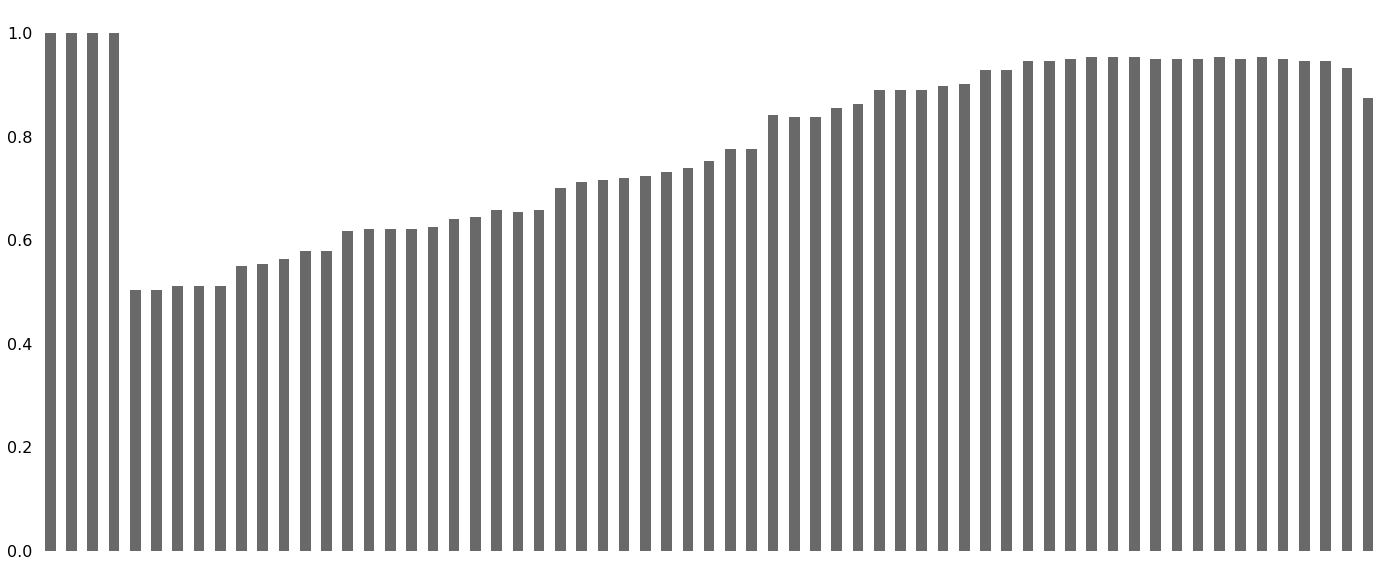

In [23]:
mno.bar(wb_gdppc_df1)

In [24]:
cols = [2,3]
wb_gdppc_df2 = wb_gdppc_df1.drop(wb_gdppc_df1.columns[cols], axis=1)
wb_gdppc_df3 = wb_gdppc_df2.rename(columns={ "Country Name": "Country", \
                                        "Country Code": "ISO_Alpha" })
wb_gdppc_df3

,Country,ISO_Alpha,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6472.502029,7885.796545,9764.789979,11392.455810,12307.311740,13496.003390,14046.504000,14936.827040,16241.046320,16439.356360,16586.068440,17927.749640,19078.343190,19356.203390,20620.700630,20669.031970,20436.887130,20833.761610,22569.974990,23300.039560,24045.272480,25835.132670,27084.703690,24630.453710,23512.602600,24985.993280,24713.698050,25025.099560,25533.569780,25796.380250,25239.600410,25630.266490,NaN
1,Afghanistan,AFG,59.773194,59.860874,58.458015,78.706388,82.095231,101.108305,137.594352,160.898589,129.108323,129.329713,156.518939,159.567578,135.317308,143.144650,173.653765,186.510897,197.445508,224.224797,247.354106,275.738198,272.655286,264.111317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,179.426495,190.684009,211.381969,242.031379,263.733735,359.693480,364.660465,438.076034,543.303042,591.162347,641.872034,637.165044,613.856333,578.466353,547.228110,556.302138,520.896603
2,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,710.981648,642.383858,619.961357,623.440585,637.715231,758.237576,685.270085,756.261853,792.303120,890.554137,947.704182,865.692730,656.361756,441.200673,328.673295,397.179451,522.643807,514.295223,423.593660,387.784316,556.836318,527.333529,872.494492,982.960899,1255.564045,1902.422346,2599.566464,3121.995637,4080.941410,3122.780766,3587.883798,4615.468028,5100.095808,5254.882338,5408.410496,4166.979684,3506.072885,4095.812942,3432.385736
3,Albania,ALB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,639.484736,639.865909,693.873475,674.793383,652.774321,697.995597,617.230435,336.586995,200.852220,367.279225,586.416340,750.604449,1009.977668,717.380567,813.790264,1033.241693,1126.683318,1281.659393,1425.124849,1846.118813,2373.579844,2673.787283,2972.743265,3595.037163,4370.539925,4114.134899,4094.358816,4437.177794,4247.614342,4413.082887,4578.667934,3952.830781,4124.108543,4532.889198,5253.630064
4,Andorra,AND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3238.556850,3498.173652,4217.173581,5342.168560,6319.739034,7169.101006,7152.375134,7751.370216,9129.706185,11820.849390,12377.411650,10372.232830,9610.266308,8022.654781,7728.906695,7774.393829,10361.815980,12616.167570,14304.356960,15166.437850,18878.505970,19532.540150,20547.711790,16516.471030,16234.809010,18461.064860,19017.174590,18353.059720,18894.521500,19261.710500,21936.530100,22228.846490,24741.493570,32776.442270,38503.479610,41282.020120,43747.691850,48582.220880,47785.089270,43338.866760,39736.354060,41100.729940,38392.943900,40626.751630,42300.334130,36039.653500,37224.108920,39134.393370,42029.762740
5,Arab World,ARB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,222.369330,237.535728,260.347312,293.484093,340.546888,419.559635,774.860012,832.035536,1002.708725,1120.662286,1191.139891,1561.383341,2051.243700,2048.663402,1862.315911,1696.684867,1669.749315,1604.000838,1486.622766,1540.010320,1472.408417,1501.826007,2007.163325,1926.490561,2024.721069,1994.346508,1986.811528,2069.987627,2233.191828,2316.393371,2186.749825,2330.191833,2603.872069,2508.212187,2474.779797,2734.318941,3132.327812,3762.767087,4356.152316,4959.915010,6143.170152,5182.363881,5945.678558,6889.091806,7503.174184,7551.282834,7497.726925,6458.702258,6202.690406,6284.737723,6625.507319
6,United Arab Emirates,ARE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26847.794380,30118.137780,33823.319650,28456.737440,33512.741330,42764.456660,44987.209800,40026.166250,34843.102900,32309.807740,29720.919470,23467.976670,2372

### Pandas `melt`, prepare WB GDP data for merge

#### GDP data

Pandas melt normalizes the dataframe to `Year`, `Country` and `value`, the latter representing `GDP` or `GDP per capita`in US dollars.

From the `pandas melt` [documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.melt.html):
> *Unpivot a DataFrame from wide format to long format, optionally leaving identifier variables set.*
>  
> *This function is useful to massage a DataFrame into a format where one or more columns are identifier variables (id_vars), while all other columns, considered measured variables (value_vars), are “unpivoted” to the row axis, leaving just two non-identifier columns, ‘variable’ and ‘value’.*

Executed as code below, from wide format to long format:

In [25]:
wb_gdp_df4 = wb_gdp_df3.melt(id_vars=['Country', 'ISO_Alpha'])

wb_gdp_df4.head()

,Country,ISO_Alpha,variable,value
0,Aruba,ABW,1960,NaN
1,Afghanistan,AFG,1960,59.773194
2,Angola,AGO,1960,NaN
3,Albania,ALB,1960,NaN
4,Andorra,AND,1960,NaN


Let's rename `variable` to `Year` and `value` to `GDP-USD`.

In [26]:
wb_gdp_df5 = wb_gdp_df4.rename(columns={'variable': 'Year', 'value': 'GDP-USD'})

wb_gdp_df5.head()

,Country,ISO_Alpha,Year,GDP-USD
0,Aruba,ABW,1960,NaN
1,Afghanistan,AFG,1960,59.773194
2,Angola,AGO,1960,NaN
3,Albania,ALB,1960,NaN
4,Andorra,AND,1960,NaN


In [27]:
wb_gdp_df5.columns

Index(['Country', 'ISO_Alpha', 'Year', 'GDP-USD'], dtype='object')

In [28]:
wb_gdp_df5.dtypes

Country       object
ISO_Alpha     object
Year          object
GDP-USD      float64
dtype: object

In [29]:
wb_gdp_df5['Year'] = pd.to_numeric(wb_gdp_df5['Year'])

In [30]:
wb_gdp_df5.dtypes

Country       object
ISO_Alpha     object
Year           int64
GDP-USD      float64
dtype: object

In [31]:
wb_gdp_df5_2017 = wb_gdp_df5.query("Year==2017")

wb_gdp_df5_2017.head()

,Country,ISO_Alpha,Year,GDP-USD
15048,Aruba,ABW,2017,25630.266490
15049,Afghanistan,AFG,2017,556.302138
15050,Angola,AGO,2017,4095.812942
15051,Albania,ALB,2017,4532.889198
15052,Andorra,AND,2017,39134.393370


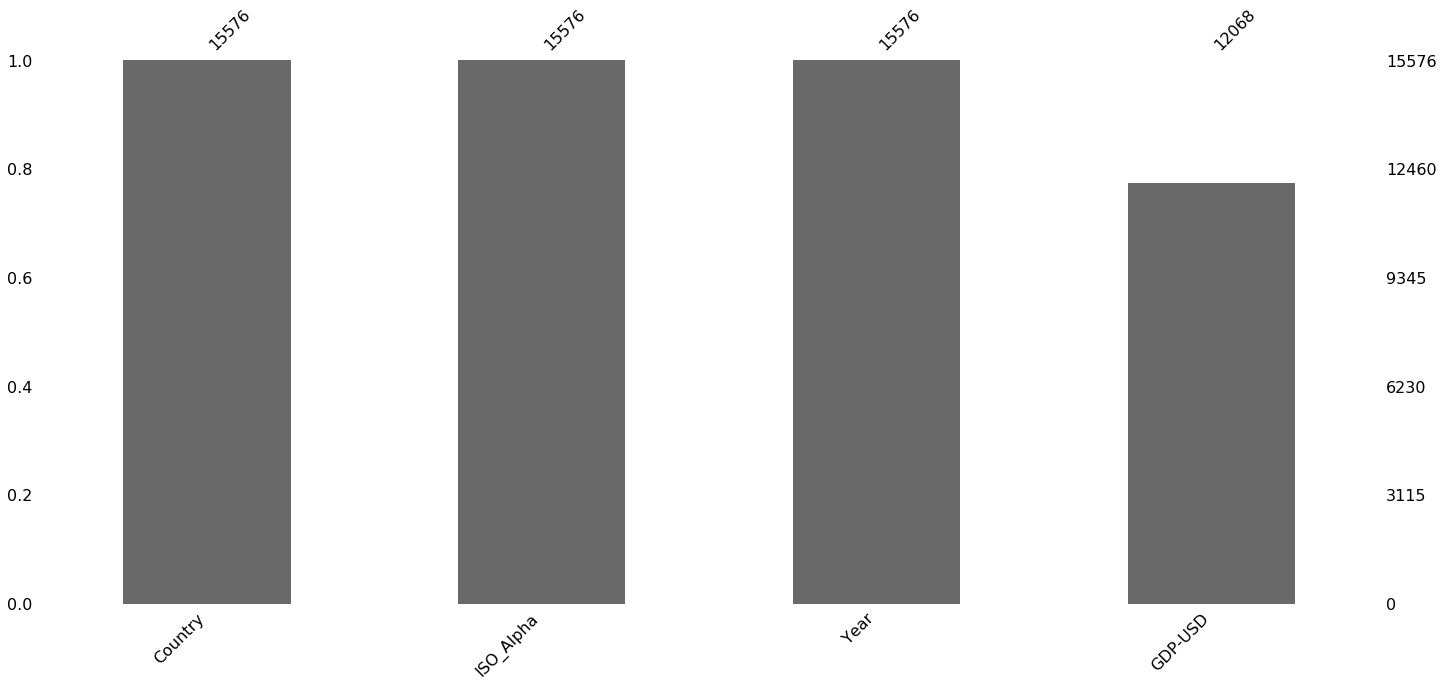

In [32]:
mno.bar(wb_gdp_df5)

#### GDP per capita data

In [33]:
wb_gdppc_df4 = wb_gdppc_df3.melt(id_vars=['Country', 'ISO_Alpha'])

wb_gdppc_df4.head()

,Country,ISO_Alpha,variable,value
0,Aruba,ABW,1960,NaN
1,Afghanistan,AFG,1960,59.773194
2,Angola,AGO,1960,NaN
3,Albania,ALB,1960,NaN
4,Andorra,AND,1960,NaN


In [34]:
wb_gdppc_df5 = wb_gdppc_df4.rename(columns={'variable': 'Year', 'value': 'GDP-PC-USD'})

wb_gdppc_df5.head()

,Country,ISO_Alpha,Year,GDP-PC-USD
0,Aruba,ABW,1960,NaN
1,Afghanistan,AFG,1960,59.773194
2,Angola,AGO,1960,NaN
3,Albania,ALB,1960,NaN
4,Andorra,AND,1960,NaN


In [35]:
wb_gdppc_df5['Year'] = pd.to_numeric(wb_gdppc_df5['Year'])

In [36]:
wb_gdppc_df5_2017 = wb_gdppc_df5.query("Year==2017")

wb_gdppc_df5_2017.head()

,Country,ISO_Alpha,Year,GDP-PC-USD
15048,Aruba,ABW,2017,25630.266490
15049,Afghanistan,AFG,2017,556.302138
15050,Angola,AGO,2017,4095.812942
15051,Albania,ALB,2017,4532.889198
15052,Andorra,AND,2017,39134.393370


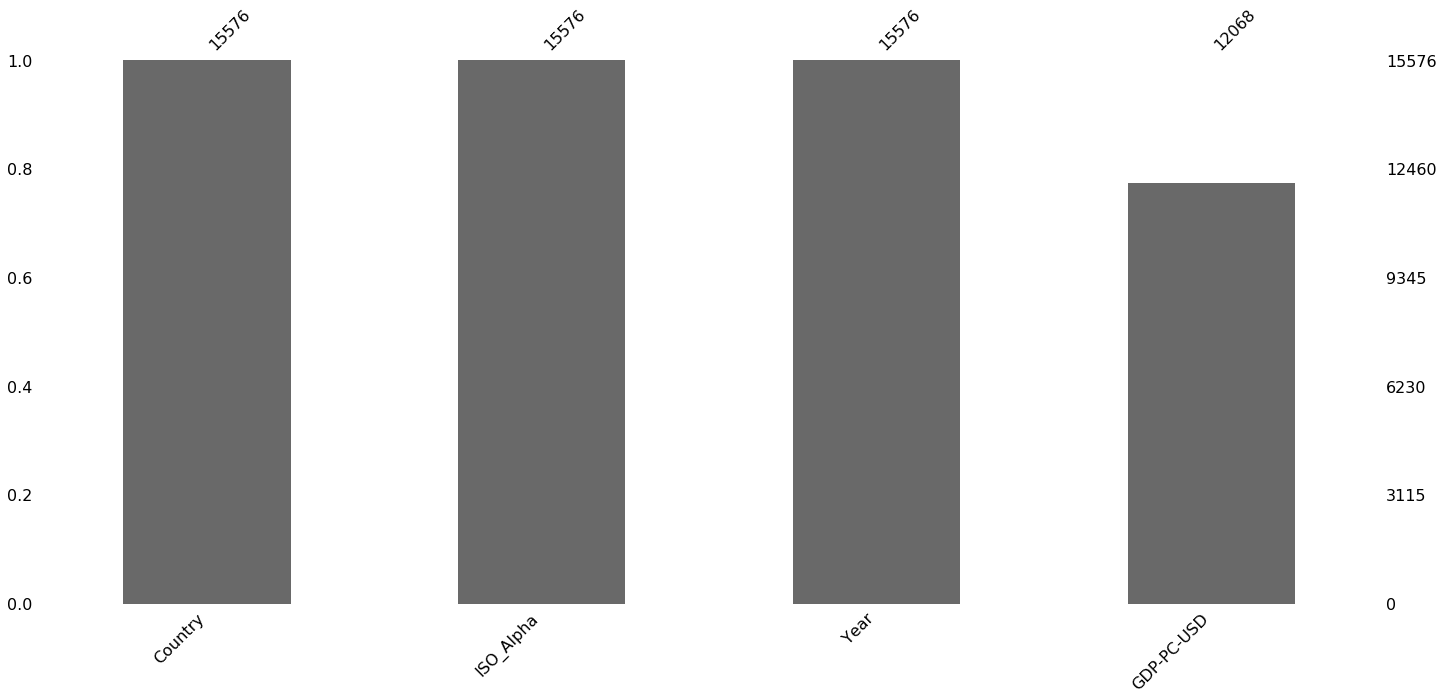

In [37]:
mno.bar(wb_gdppc_df5)

### World Bank metadata updates

In [38]:
wb_gdp_meta_df1 = pd.read_csv("resources/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_123.csv")

wb_gdp_meta_df1.head()

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFG,South Asia,Low income,NaN,Afghanistan,NaN
2,AGO,Sub-Saharan Africa,Lower middle income,NaN,Angola,NaN
3,ALB,Europe & Central Asia,Upper middle income,NaN,Albania,NaN
4,AND,Europe & Central Asia,High income,NaN,Andorra,NaN


Let's rename some columns in the WB dataframe above in preparation for dataframe merge. Let's also drop the `Unnamed: 5` and  `SpecialNotes` columns.

In [39]:
wb_gdp_meta_df2 = wb_gdp_meta_df1.rename(\
        columns={'TableName': 'Country', 'Country Code': 'ISO_Alpha'})
wb_gdp_meta_df3 = wb_gdp_meta_df2.drop(['Unnamed: 5', 'SpecialNotes'], axis=1)

wb_gdp_meta_df3.head()

,ISO_Alpha,Region,IncomeGroup,Country
0,ABW,Latin America & Caribbean,High income,Aruba
1,AFG,South Asia,Low income,Afghanistan
2,AGO,Sub-Saharan Africa,Lower middle income,Angola
3,ALB,Europe & Central Asia,Upper middle income,Albania
4,AND,Europe & Central Asia,High income,Andorra


### Check linkage column, `ISO_Alpha`, before Merge #1

Because we are going to merge WB data and metadata on the `ISO_Alpha` column, we have to check if the data from the `ISO_Alpha` columns from both dataframes match.

To do this we will construct two dataframes that we can visually inspect and compare: `wb_gdp_c1` and `wb_gdp_c2`.

In [40]:
wb_gdp_iso3 = wb_gdp_df5.ISO_Alpha.unique()
wb_gdp_country = wb_gdp_df5.Country.unique()

wb_gdp_c1 = pd.DataFrame({'ISO_Alpha':wb_gdp_iso3,'Country':wb_gdp_country})

wb_gdp_c1

,ISO_Alpha,Country
0,ABW,Aruba
1,AFG,Afghanistan
2,AGO,Angola
3,ALB,Albania
4,AND,Andorra
5,ARB,Arab World
6,ARE,United Arab Emirates
7,ARG,Argentina
8,ARM,Armenia
9,ASM,American Samoa


In [41]:
wb_gdp_meta_iso3 = wb_gdp_meta_df3.ISO_Alpha.unique()
wb_gdp_meta_country = wb_gdp_meta_df3.Country.unique()

wb_gdp_c2 = pd.DataFrame({'ISO_Alpha':wb_gdp_meta_iso3,'Country':wb_gdp_meta_country})

wb_gdp_c2

,ISO_Alpha,Country
0,ABW,Aruba
1,AFG,Afghanistan
2,AGO,Angola
3,ALB,Albania
4,AND,Andorra
5,ARB,Arab World
6,ARE,United Arab Emirates
7,ARG,Argentina
8,ARM,Armenia
9,ASM,American Samoa


Using a `numpy` dot function called `setdiff1d()`, let's check which `Country` names `ISO_Alpha` codes don't overlap between WB GDP data and metadata.

In [42]:
wb_nonmatch = np.setdiff1d(wb_gdp_iso3, wb_gdp_meta_iso3)

wb_nonmatch

array(['INX'], dtype=object)

If you check the value `INX`, it does not represent a country.

#### Pickle WB dataframes

In [43]:
wb_gdp_df5.to_pickle('outputs/wb_gdp_df5.pickle')
wb_gdppc_df5.to_pickle('outputs/wb_gdppc_df5.pickle')
wb_gdp_meta_df3.to_pickle('outputs/wb_gdp_meta_df3.pickle')

### 3. WB Education Data, 1960-2018

From the World Bank education page (link below):

> *"Education is one of the most powerful instruments for reducing poverty and inequality and lays a foundation for sustained economic growth. The World Bank compiles data on education inputs, participation, efficiency, and outcomes. Data on education are compiled by the United Nations Educational, Scientific, and Cultural Organization (UNESCO) Institute for Statistics from official responses to surveys and from reports provided by education authorities in each country."*

1. Source: http://api.worldbank.org/v2/en/topic/4?downloadformat=csv (version: 7/10/2019)
2. License: https://datacatalog.worldbank.org/public-licenses#cc-by
3. Note: The downloaded zip file has 3 CSV files: data, metadata and indicator metatadata (first two are used here). The data CSV file has 4 rows at the top that should be deleted. The metadata file has complete descriptions of indicators, including data sources (see below).

### Aggregate data, WB education indicators

In [44]:
wb_ed_df1 = pd.read_csv('resources/API_4_DS2_en_csv_v2_48246 V2.csv')

wb_ed_df1.head(30)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Aruba,ABW,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,53.669919,54.056784,54.383281,54.710292,55.119933,55.631102,56.075544,56.703126,57.414449,58.086708,58.679715,59.55249,60.248997,60.890062,61.639241,62.566563,63.078929,63.850512,64.825383,65.810270,66.635051,67.185101,67.578450,67.804376,67.945127,68.154412,67.755890,67.567480,67.614074,67.749705,67.796747,68.523104,69.021763,69.298246,69.471969,69.667845,69.450721,69.326281,69.279421,69.261277,69.240421,69.323344,69.421636,69.554820,69.734750,69.935320,69.856791,69.691761,69.448364,69.161089,68.838092,68.882835,68.976476,69.090099,69.165181,69.159774,69.152468,69.003648,68.762184
1,Aruba,ABW,Population ages 0-14 (% of total population),SP.POP.0014.TO.ZS,43.847190,43.358346,42.925745,42.488756,41.950133,41.290098,40.689595,39.900095,39.011064,38.134727,37.316086,36.08681,35.015040,33.989011,32.869085,31.577559,30.878421,29.907564,28.734007,27.542514,26.514244,25.829247,25.314207,25.001206,24.785155,24.527973,24.862716,24.976954,24.853059,24.641172,24.547459,24.084677,23.804499,23.685590,23.598435,23.420148,23.562500,23.583106,23.490725,23.348127,23.179202,22.918685,22.622958,22.277539,21.882374,21.473343,21.224413,21.078838,21.002832,20.947631,20.873619,20.533448,20.104897,19.614874,19.130979,18.703098,18.241400,17.911157,17.661588
2,Aruba,ABW,"Unemployment, total (% of total labor force) (modeled ILO estimate)",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,"Unemployment, male (% of male labor force) (modeled ILO estimate)",SL.UEM.TOTL.MA.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,"Unemployment, female (% of female labor force) (modeled ILO estimate)",SL.UEM.TOTL.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Aruba,ABW,"Labor force, total",SL.TLF.TOTL.IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Aruba,ABW,"Labor force, female (% of total labor force)",SL.TLF.TOTL.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Aruba,ABW,"Government expenditure on education, total (% of GDP)",SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.763160,4.395540,4.714680,4.739490,4.924270,NaN,4.408900,4.680760,NaN,4.799180,4.915590,5.924670,6.712490,6.036870,6.549060,6.808060,6.162930,6.479060,6.143220,NaN,NaN
8,Aruba,ABW,"Government expenditure on education, total (% of government expenditure)",SE.XPD.TOTL.GB.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

### Indicator metadata, WB education indicators

In [45]:
wb_edmeta_df1 = \
  pd.read_csv('resources/Metadata_Indicator_API_4_DS2_en_csv_v2_48246.csv').\
    drop(['Unnamed: 4'], axis=1)

wb_edmeta_df1.head(160)

,INDICATOR_CODE,INDICATOR_NAME,SOURCE_NOTE,SOURCE_ORGANIZATION
0,SP.POP.1564.TO.ZS,Population ages 15-64 (% of total population),"Total population between the ages 15 to 64 as a percentage of the total population. Population is based on the de facto definition of population, ...",World Bank staff estimates based on age/sex distributions of United Nations Population Division's World Population Prospects: 2017 Revision.
1,SP.POP.0014.TO.ZS,Population ages 0-14 (% of total population),Population between the ages 0 to 14 as a percentage of the total population. Population is based on the de facto definition of population.,World Bank staff estimates based on age/sex distributions of United Nations Population Division's World Population Prospects: 2017 Revision.
2,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (modeled ILO estimate)",Unemployment refers to the share of the labor force that is without work but available for and seeking employment.,"International Labour Organization, ILOSTAT database. Data retrieved in April 2019."
3,SL.UEM.TOTL.MA.ZS,"Unemployment, male (% of male labor force) (modeled ILO estimate)",Unemployment refers to the share of the labor force that is without work but available for and seeking employment.,"International Labour Organization, ILOSTAT database. Data retrieved in April 2019."
4,SL.UEM.TOTL.FE.ZS,"Unemployment, female (% of female labor force) (modeled ILO estimate)",Unemployment refers to the share of the labor force that is without work but available for and seeking employment.,"International Labour Organization, ILOSTAT database. Data retrieved in April 2019."
5,SL.TLF.TOTL.IN,"Labor force, total",Labor force comprises people ages 15 and older who supply labor for the production of goods and services during a specified period. It includes pe...,"Derived using data from International Labour Organization, ILOSTAT database and World Bank population estimates. Labor data retrieved in April 2019."
6,SL.TLF.TOTL.FE.ZS,"Labor force, female (% of total labor force)",Female labor force as a percentage of the total show the extent to which women are active in the labor force. Labor force comprises people ages 15...,"Derived using data from International Labour Organization, ILOSTAT database and World Bank population estimates. Labor data retrieved in April 2019."
7,SE.XPD.TOTL.GD.ZS,"Government expenditure on education, total (% of GDP)","General government expenditure on education (current, capital, and transfers) is expressed as a percentage of GDP. It includes expenditure funded ...",UNESCO Institute for Statistics (http://uis.unesco.org/)
8,SE.XPD.TOTL.GB.ZS,"Government expenditure on education, total (% of government expenditure)","General government expenditure on education (current, capital, and transfers) is expressed as a percentage of total general government expenditure...",UNESCO Institute for Statistics (http://uis.unesco.org/)
9,SE.XPD.TERT.ZS,Expenditure on tertiary education (% of government expenditure on education),Expenditure on tertiary education is expressed as a percentage of total general government expenditure on education. General government usually re...,UNESCO Institute for Statistics (http://uis.unesco.org/)


Let's rename some columns of the education data set. Note that this data set has several indicators referenced in the metadata data above.

In [46]:
wb_ed_df2 = wb_ed_df1.rename(columns={ "Country Name": "Country", \
                                        "Country Code": "ISO_Alpha", \
                                       "Indicator Name": "Indicator_Name", \
                                       "Indicator Code": "Indicator_Code"})
wb_ed_df2.head(30)

,Country,ISO_Alpha,Indicator_Name,Indicator_Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Aruba,ABW,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,53.669919,54.056784,54.383281,54.710292,55.119933,55.631102,56.075544,56.703126,57.414449,58.086708,58.679715,59.55249,60.248997,60.890062,61.639241,62.566563,63.078929,63.850512,64.825383,65.810270,66.635051,67.185101,67.578450,67.804376,67.945127,68.154412,67.755890,67.567480,67.614074,67.749705,67.796747,68.523104,69.021763,69.298246,69.471969,69.667845,69.450721,69.326281,69.279421,69.261277,69.240421,69.323344,69.421636,69.554820,69.734750,69.935320,69.856791,69.691761,69.448364,69.161089,68.838092,68.882835,68.976476,69.090099,69.165181,69.159774,69.152468,69.003648,68.762184
1,Aruba,ABW,Population ages 0-14 (% of total population),SP.POP.0014.TO.ZS,43.847190,43.358346,42.925745,42.488756,41.950133,41.290098,40.689595,39.900095,39.011064,38.134727,37.316086,36.08681,35.015040,33.989011,32.869085,31.577559,30.878421,29.907564,28.734007,27.542514,26.514244,25.829247,25.314207,25.001206,24.785155,24.527973,24.862716,24.976954,24.853059,24.641172,24.547459,24.084677,23.804499,23.685590,23.598435,23.420148,23.562500,23.583106,23.490725,23.348127,23.179202,22.918685,22.622958,22.277539,21.882374,21.473343,21.224413,21.078838,21.002832,20.947631,20.873619,20.533448,20.104897,19.614874,19.130979,18.703098,18.241400,17.911157,17.661588
2,Aruba,ABW,"Unemployment, total (% of total labor force) (modeled ILO estimate)",SL.UEM.TOTL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aruba,ABW,"Unemployment, male (% of male labor force) (modeled ILO estimate)",SL.UEM.TOTL.MA.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aruba,ABW,"Unemployment, female (% of female labor force) (modeled ILO estimate)",SL.UEM.TOTL.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Aruba,ABW,"Labor force, total",SL.TLF.TOTL.IN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Aruba,ABW,"Labor force, female (% of total labor force)",SL.TLF.TOTL.FE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Aruba,ABW,"Government expenditure on education, total (% of GDP)",SE.XPD.TOTL.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.763160,4.395540,4.714680,4.739490,4.924270,NaN,4.408900,4.680760,NaN,4.799180,4.915590,5.924670,6.712490,6.036870,6.549060,6.808060,6.162930,6.479060,6.143220,NaN,NaN
8,Aruba,ABW,"Government expenditure on education, total (% of government expenditure)",SE.XPD.TOTL.GB.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

### Education data subsets

The education data set contains many indicators. We will pick one indicator to merge with other GDP indicators.

#### Primary completion rate

Let's query the metadata for a full description of the primary completion rate indicator. (Note: You can apply the same steps to other education indicators found in the data set.

In [ ]:
# first line disables the column width default so we can see
#   the full text of `SOURCE NOTES` column
# the second line prints the row corresponding to the indicator code
#   for primary completion rate
with pd.option_context('display.max_colwidth', None): 
    print(wb_edmeta_df1.query("INDICATOR_CODE=='SE.PRM.CMPT.ZS'"))

     INDICATOR_CODE                                            INDICATOR_NAME  \
130  SE.PRM.CMPT.ZS  Primary completion rate, total (% of relevant age group)   

                                                                                                                                                                                                                                                                                                                                                                                                        SOURCE_NOTE  \
130  Primary completion rate, or gross intake ratio to the last grade of primary education, is the number of new entrants (enrollments minus repeaters) in the last grade of primary education, regardless of age, divided by the population at the entrance age for the last grade of primary education. Data limitations preclude adjusting for students who drop out during the final year of primary education.   

                      

In [48]:
wb_ed_primcomp_df1 = wb_ed_df2.query("Indicator_Code=='SE.PRM.CMPT.ZS'")

wb_ed_primcomp_df1

,Country,ISO_Alpha,Indicator_Name,Indicator_Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
130,Aruba,ABW,"Primary completion rate, total (% of relevant age group)",SE.PRM.CMPT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.619118,97.142860,94.404068,94.755241,90.215919,90.559898,88.197968,93.186119,95.588242,95.133034,96.242577,94.786102,NaN,NaN,96.570641,101.180557,NaN,NaN,NaN,NaN
284,Afghanistan,AFG,"Primary completion rate, total (% of relevant age group)",SE.PRM.CMPT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.794571,NaN,NaN,18.049200,19.835131,NaN,26.619160,33.067390,NaN,NaN,18.200041,18.909081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.069651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438,Angola,AGO,"Primary completion rate, total (% of relevant age group)",SE.PRM.CMPT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.097050,36.053768,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.555300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.270191,38.839180,39.806419,46.086109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
592,Albania,ALB,"Primary completion rate, total (% of relevant age group)",SE.PRM.CMPT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.024391,NaN,NaN,NaN,97.073212,96.880661,NaN,94.902428,93.870880,NaN,NaN,96.629097,92.830223,91.512283,89.237343,93.277008,98.911697,90.974411,105.002121,104.468193,105.604103,106.732292,NaN
746,Andorra,AND,"Primary completion rate, total (% of relevant age group)",SE.PRM.CMPT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
900,Arab World,ARB,"Primary completion rate, total (% of relevant age group)",SE.PRM.CMPT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.694698,49.610611,49.221371,50.707932,52.152161,55.056381,56.590752,58.593521,57.903080,53.698662,56.693192,60.055500,60.776131,61.925030,64.244164,68.244659,67.293877,67.163406,67.547249,67.663109,68.912369,68.879730,69.615913,69.794983,70.596321,71.592758,72.598328,73.399406,74.340240,75.264481,74.816620,75.948402,76.856773,79.329163,81.263092,82.122704,80.572083,82.618568,84.814346,83.495071,85.275780,85.900818,87.216766,84.703484,85.255699,84.703758,84.079933,84.267082,NaN
1054,United Arab Emirates,ARE,"Primary completion rate, total (% of relevant age group)",SE.PRM.CMPT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.088001,41.208069,48.784458,55.893711,59.730709,64.619049,66.985397,71.119781,80.479759,79.883080,76.881241,73.029320,74.639954,75.089401,73.468697,80.836273,89.602737,96.038757,94.518082,92.034142,90.802330,88.815628,84.853012,86.836472,84.431313,83.093407,79.819542,76.231239,80.136543,NaN,NaN,NaN,NaN,97.162354,NaN,NaN,NaN,NaN,95.006126,96.987419,100.742210,105.186089,NaN,NaN,NaN
1208,Argentina,ARG,"Primary completion rate, total (% of relevant age group)",SE.PRM.CMPT.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.722672,71.573967,NaN,NaN,75.313377,78.720139,78.639381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.680908,NaN,93.618874,92.180717,100.086517,98.217644,98.493736,98.086487,102.030724,99.923820,98.562859,96.684792,99.133202,101.852600,105.063500,104.985947,104.809532,104.423714,103.231369,100.882889,101.810761,101.480187,102.445480,NaN,NaN
1362,Armenia,ARM,"Primary completion rate, total (% of relevant age group)",SE.PRM.

Let's use `missingo` with alias `mno` to inspect missing values for this indicator across years of data collection.

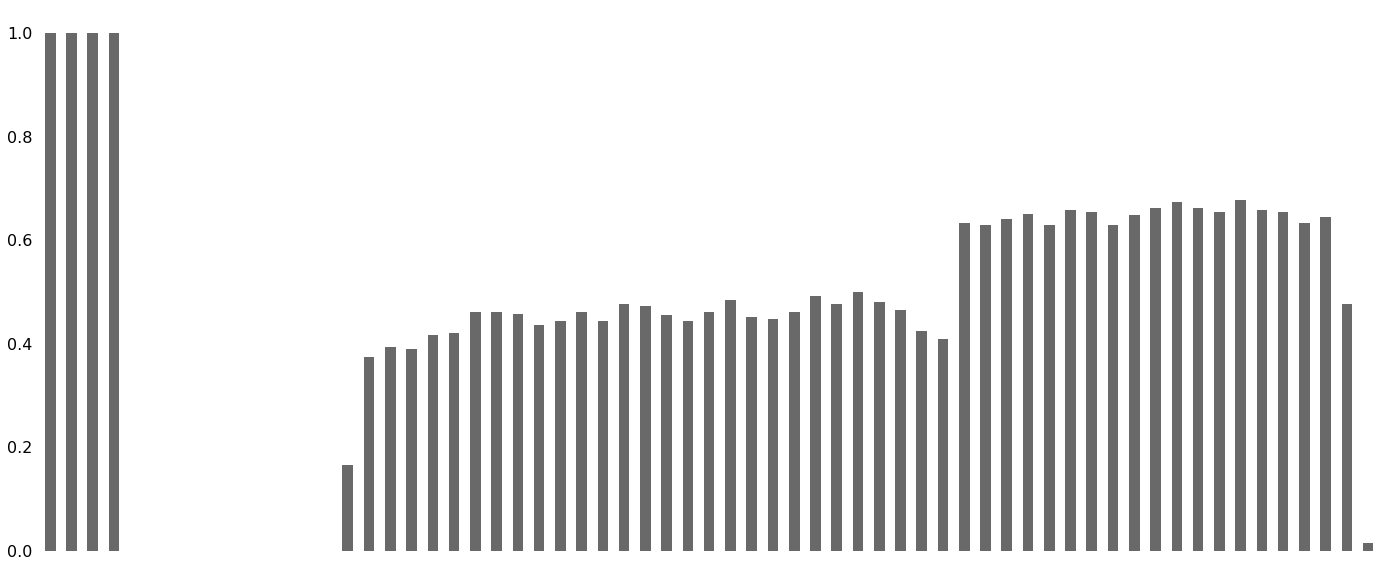

In [49]:
mno.bar(wb_ed_primcomp_df1)

This data set being a subset for primary completion rate indicator, we will not need the Indicator_Code and Indicator_Name columns so we drop these using the code below.

In [50]:
cols = [2,3]
wb_ed_primcomp_df2 = wb_ed_primcomp_df1.drop(wb_ed_primcomp_df1.columns[cols],axis=1)

wb_ed_primcomp_df2

,Country,ISO_Alpha,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
130,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.619118,97.142860,94.404068,94.755241,90.215919,90.559898,88.197968,93.186119,95.588242,95.133034,96.242577,94.786102,NaN,NaN,96.570641,101.180557,NaN,NaN,NaN,NaN
284,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.794571,NaN,NaN,18.049200,19.835131,NaN,26.619160,33.067390,NaN,NaN,18.200041,18.909081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.069651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
438,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.097050,36.053768,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.555300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.270191,38.839180,39.806419,46.086109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
592,Albania,ALB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.024391,NaN,NaN,NaN,97.073212,96.880661,NaN,94.902428,93.870880,NaN,NaN,96.629097,92.830223,91.512283,89.237343,93.277008,98.911697,90.974411,105.002121,104.468193,105.604103,106.732292,NaN
746,Andorra,AND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
900,Arab World,ARB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.694698,49.610611,49.221371,50.707932,52.152161,55.056381,56.590752,58.593521,57.903080,53.698662,56.693192,60.055500,60.776131,61.925030,64.244164,68.244659,67.293877,67.163406,67.547249,67.663109,68.912369,68.879730,69.615913,69.794983,70.596321,71.592758,72.598328,73.399406,74.340240,75.264481,74.816620,75.948402,76.856773,79.329163,81.263092,82.122704,80.572083,82.618568,84.814346,83.495071,85.275780,85.900818,87.216766,84.703484,85.255699,84.703758,84.079933,84.267082,NaN
1054,United Arab Emirates,ARE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.088001,41.208069,48.784458,55.893711,59.730709,64.619049,66.985397,71.119781,80.479759,79.883080,76.881241,73.029320,74.639954,75.089401,73.468697,80.836273,89.602737,96.038757,94.518082,92.034142,90.802330,88.815628,84.853012,86.836472,84.431313,83.093407,79.819542,76.231239,80.136543,NaN,NaN,NaN,NaN,97.162354,NaN,NaN,NaN,NaN,95.006126,96.987419,100.742210,105.186089,NaN,NaN,NaN
1208,Argentina,ARG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.722672,71.573967,NaN,NaN,75.313377,78.720139,78.639381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.680908,NaN,93.618874,92.180717,100.086517,98.217644,98.493736,98.086487,102.030724,99.923820,98.562859,96.684792,99.133202,101.852600,105.063500,104.985947,104.809532,104.423714,103.231369,100.882889,101.810761,101.480187,102.445480,NaN,NaN
1362,Armenia,ARM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,108.263802,NaN,NaN,93.895500,NaN,NaN,NaN,NaN,93.707390,89.272758,100.047470,92.691582,93.811211,102.067139,105.790024,NaN,94.495232,93.808968,93.898399,NaN,96.641220,94.366547,90.387321,91.611588,NaN
1516,American Samoa,ASM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Pandas `melt`, prepare WB education data for merge

#### Primary completion rate

In [51]:
wb_ed_primcomp_df3 = wb_ed_primcomp_df2.melt(\
            id_vars=['Country', 'ISO_Alpha'])

wb_ed_primcomp_df3.head(200)

,Country,ISO_Alpha,variable,value
0,Aruba,ABW,1960,NaN
1,Afghanistan,AFG,1960,NaN
2,Angola,AGO,1960,NaN
3,Albania,ALB,1960,NaN
4,Andorra,AND,1960,NaN
5,Arab World,ARB,1960,NaN
6,United Arab Emirates,ARE,1960,NaN
7,Argentina,ARG,1960,NaN
8,Armenia,ARM,1960,NaN
9,American Samoa,ASM,1960,NaN


In [52]:
wb_ed_primcomp_df4 = \
    wb_ed_primcomp_df3.rename(columns={'variable': 'Year', 'value':'Value'})
wb_ed_primcomp_df4['Year'] = pd.to_numeric(wb_ed_primcomp_df4['Year'])

wb_ed_primcomp_df4.head()

,Country,ISO_Alpha,Year,Value
0,Aruba,ABW,1960,NaN
1,Afghanistan,AFG,1960,NaN
2,Angola,AGO,1960,NaN
3,Albania,ALB,1960,NaN
4,Andorra,AND,1960,NaN


### Visually explore "pivoted" dataframes

#### Primary education completion rate

From the `pandas pivot` [documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html):
> *Return reshaped DataFrame organized by given index / column values.*
>  
> *Reshape data (produce a “pivot” table) based on column values. Uses unique values from specified index / columns to form axes of the resulting DataFrame. This function does not support data aggregation, multiple values will result in a MultiIndex in the columns. See the User Guide for more on reshaping.*

Executed as code below, from long format to wide format:

In [53]:
wb_ed_primcomp_pivot_df4 = \
    wb_ed_primcomp_df4.pivot(index='Year', columns='Country', values='Value')

wb_ed_primcomp_pivot_df4.head()

Country,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Antigua and Barbuda,Arab World,Argentina,Armenia,Aruba,Australia,Austria,Azerbaijan,"Bahamas, The",Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bermuda,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Brazil,British Virgin Islands,Brunei Darussalam,Bulgaria,Burkina Faso,Burundi,Cabo Verde,Cambodia,Cameroon,Canada,Caribbean small states,Cayman Islands,Central African Republic,Central Europe and the Baltics,Chad,Channel Islands,Chile,China,Colombia,Comoros,"Congo, Dem. Rep.","Congo, Rep.",Costa Rica,Cote d'Ivoire,Croatia,Cuba,Curacao,Cyprus,Czech Republic,Denmark,Djibouti,Dominica,Dominican Republic,Early-demographic dividend,East Asia & Pacific,East Asia & Pacific (IDA & IBRD countries),East Asia & Pacific (excluding high income),Ecuador,"Egypt, Arab Rep.",El Salvador,Equatorial Guinea,Eritrea,Estonia,Eswatini,Ethiopia,Euro area,Europe & Central Asia,Europe & Central Asia (IDA & IBRD countries),...,Papua New Guinea,Paraguay,Peru,Philippines,Poland,Portugal,Post-demographic dividend,Pre-demographic dividend,Puerto Rico,Qatar,Romania,Russian Federation,Rwanda,Samoa,San Marino,Sao Tome and Principe,Saudi Arabia,Senegal,Serbia,Seychelles,Sierra Leone,Singapore,Sint Maarten (Dutch part),Slovak Republic,Slovenia,Small states,Solomon Islands,Somalia,South Africa,South Asia,South Asia (IDA & IBRD),South Sudan,Spain,Sri Lanka,St. Kitts and Nevis,St. Lucia,St. Martin (French part),St. Vincent and the Grenadines,Sub-Saharan Africa,Sub-Saharan Africa (IDA & IBRD countries),Sub-Saharan Africa (excluding high income),Sudan,Suriname,Sweden,Switzerland,Syrian Arab Republic,Tajikistan,Tanzania,Thailand,Timor-Leste,Togo,Tonga,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,Turks and Caicos Islands,Tuvalu,Uganda,Ukraine,United Arab Emirates,United Kingdom,United States,Upper middle income,Uruguay,Uzbekistan,Vanuatu,"Venezuela, RB",Vietnam,Virgin Islands (U.S.),West Bank and Gaza,World,"Yemen, Rep.",Zambia,Zimbabwe
Year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1963,NaN,NaN,

Text(0, 0.5, 'Completion Rate')

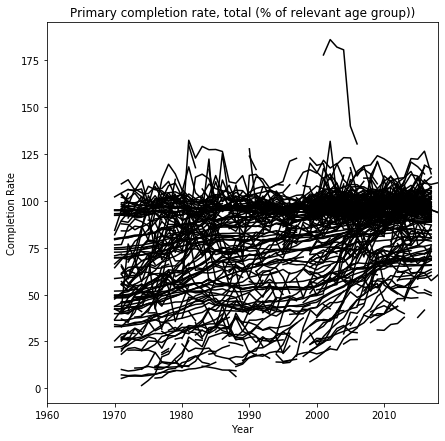

In [54]:
ax = wb_ed_primcomp_pivot_df4.plot(\
    legend=False, \
    color=['black'], \
    figsize=(7,7),\
    title='Primary completion rate, total (% of relevant age group))')
ax.set_xlabel("Year")
ax.set_ylabel("Completion Rate")

Let's look at those countries with completion rate > 125.

In [55]:
wb_ed_primcomp_df4.query("Value>125")

,Country,ISO_Alpha,Year,Value
5666,Kiribati,KIR,1981,132.345017
5781,Tonga,TON,1981,129.578537
6194,Kiribati,KIR,1983,129.071426
6458,Kiribati,KIR,1984,127.299927
6722,Kiribati,KIR,1985,127.434311
6986,Kiribati,KIR,1986,126.363640
7029,Mauritius,MUS,1986,125.323357
8157,Tonga,TON,1990,127.770699
10974,Maldives,MDV,2001,177.848923
11111,Belarus,BLR,2002,131.797378


#### Pickle WB education data

In [56]:
wb_ed_df2.to_pickle('outputs/wb_ed_df2.pickle')
wb_edmeta_df1.to_pickle('outputs/wb_edmeta_df1.pickle')
wb_ed_primcomp_df4.to_pickle('outputs/wb_ed_primcomp_df4.pickle')

### 4. WB data on health care per capita spending, 1960-2018

1. Source: http://api.worldbank.org/v2/en/indicator/SH.XPD.CHEX.PC.CD?downloadformat=csv (version: 7/10/2019)
2. License: https://datacatalog.worldbank.org/public-licenses#cc-by
3. Note: The downloaded zip file has 3 CSV files: data, metadata and indicator metatadata (first two are used here). The data CSV file has 4 rows at the top that should be deleted. You can further explore which columns actually have data (columns for earlier years might be empty for all countries).

#### Aggregate data, health care per capita spending

In [57]:
wb_hcpcs_df1 = pd.read_csv('resources/API_SH.XPD.CHEX.PC.CD_DS2_en_csv_v2_41516 V2.csv')

wb_hcpcs_df1.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Aruba,ABW,Current health expenditure per capita (current US$),SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,Current health expenditure per capita (current US$),SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.249542,17.490737,20.927087,24.446512,28.416662,31.840183,38.700492,42.304510,45.587750,51.553259,52.218506,55.967550,60.112761,60.088813,57.248760,NaN,NaN
2,Angola,AGO,Current health expenditure per capita (current US$),SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.963033,28.854245,28.961365,34.718297,49.526718,53.930701,69.424700,92.452016,135.208309,119.808614,96.643701,122.117809,122.242944,143.703204,131.751875,108.680670,95.220799,NaN,NaN
3,Albania,ALB,Current health expenditure per capita (current US$),SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.531472,81.946417,89.858329,113.583982,151.980517,165.865512,172.795596,216.413135,239.684351,206.944820,203.208588,246.803760,246.742546,277.668997,313.262897,264.434603,271.543043,NaN,NaN
4,Andorra,AND,Current health expenditure per capita (current US$),SH.XPD.CHEX.PC.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2050.647513,2081.275330,2256.349073,2774.089627,3161.482406,3536.122706,3689.705702,4094.544269,4201.729595,3911.895963,3754.731346,4013.911834,3857.161116,4107.733984,4346.258747,3698.117574,3834.730581,NaN,NaN


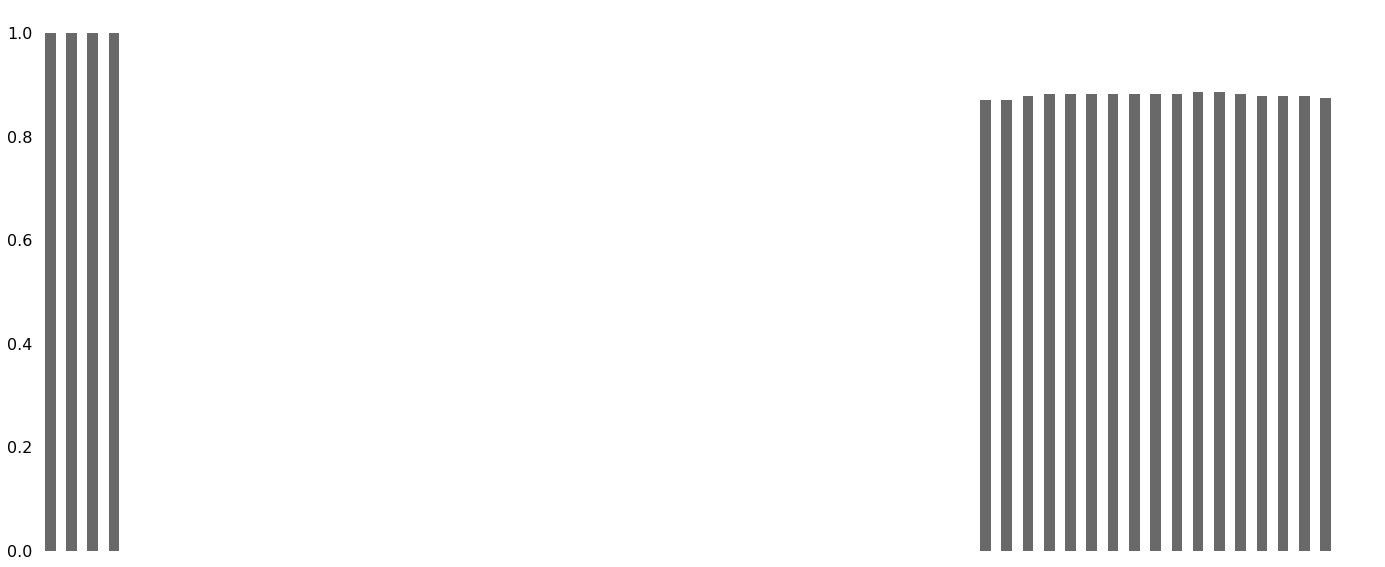

In [58]:
mno.bar(wb_hcpcs_df1)

Because this data set is just about one indicator, health care per capita spending, let's drop the two columns, `Indicator Name` and `Indicator Code`, drop the columns from `1960` to `1999` because they are empty, and rename `Country Name` to `Country` and `Country Code` to `ISO_Alpha`.

In [59]:
wb_hcpcs_df2 = wb_hcpcs_df1.drop(wb_hcpcs_df1.iloc[:, 2:44], axis=1)

wb_hcpcs_df2.head()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,NaN,NaN,16.249542,17.490737,20.927087,24.446512,28.416662,31.840183,38.700492,42.304510,45.587750,51.553259,52.218506,55.967550,60.112761,60.088813,57.248760,NaN,NaN
2,Angola,AGO,12.963033,28.854245,28.961365,34.718297,49.526718,53.930701,69.424700,92.452016,135.208309,119.808614,96.643701,122.117809,122.242944,143.703204,131.751875,108.680670,95.220799,NaN,NaN
3,Albania,ALB,75.531472,81.946417,89.858329,113.583982,151.980517,165.865512,172.795596,216.413135,239.684351,206.944820,203.208588,246.803760,246.742546,277.668997,313.262897,264.434603,271.543043,NaN,NaN
4,Andorra,AND,2050.647513,2081.275330,2256.349073,2774.089627,3161.482406,3536.122706,3689.705702,4094.544269,4201.729595,3911.895963,3754.731346,4013.911834,3857.161116,4107.733984,4346.258747,3698.117574,3834.730581,NaN,NaN


In [60]:
wb_hcpcs_df3 = wb_hcpcs_df2.iloc[:, :-2]

wb_hcpcs_df3.head()

,Country Name,Country Code,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,NaN,NaN,16.249542,17.490737,20.927087,24.446512,28.416662,31.840183,38.700492,42.304510,45.587750,51.553259,52.218506,55.967550,60.112761,60.088813,57.248760
2,Angola,AGO,12.963033,28.854245,28.961365,34.718297,49.526718,53.930701,69.424700,92.452016,135.208309,119.808614,96.643701,122.117809,122.242944,143.703204,131.751875,108.680670,95.220799
3,Albania,ALB,75.531472,81.946417,89.858329,113.583982,151.980517,165.865512,172.795596,216.413135,239.684351,206.944820,203.208588,246.803760,246.742546,277.668997,313.262897,264.434603,271.543043
4,Andorra,AND,2050.647513,2081.275330,2256.349073,2774.089627,3161.482406,3536.122706,3689.705702,4094.544269,4201.729595,3911.895963,3754.731346,4013.911834,3857.161116,4107.733984,4346.258747,3698.117574,3834.730581


In [61]:
wb_hcpcs_df4 = wb_hcpcs_df3.rename(columns={ "Country Name": "Country", \
                                        "Country Code": "ISO_Alpha" })
wb_hcpcs_df4.head()

,Country,ISO_Alpha,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,NaN,NaN,16.249542,17.490737,20.927087,24.446512,28.416662,31.840183,38.700492,42.304510,45.587750,51.553259,52.218506,55.967550,60.112761,60.088813,57.248760
2,Angola,AGO,12.963033,28.854245,28.961365,34.718297,49.526718,53.930701,69.424700,92.452016,135.208309,119.808614,96.643701,122.117809,122.242944,143.703204,131.751875,108.680670,95.220799
3,Albania,ALB,75.531472,81.946417,89.858329,113.583982,151.980517,165.865512,172.795596,216.413135,239.684351,206.944820,203.208588,246.803760,246.742546,277.668997,313.262897,264.434603,271.543043
4,Andorra,AND,2050.647513,2081.275330,2256.349073,2774.089627,3161.482406,3536.122706,3689.705702,4094.544269,4201.729595,3911.895963,3754.731346,4013.911834,3857.161116,4107.733984,4346.258747,3698.117574,3834.730581


#### Pickle WB HCPCS data

In [62]:
wb_hcpcs_df4.to_pickle('outputs/wb_hcpcs_df4.pickle')

## You finished Notebook 2!

Please proceed to Notebook 3.

## Note

Although you finished Notebook 2, where all data sets are loaded and processed, the World Bank data catalog has many more data sets that could be explored, related to poverty, climate, infrastructure, and others.